# 01 — Yield Curve Bootstrap

**Goal:** transform deposit and swap quotes into discount factors, zero rates and forward rates, then validate the bootstrap by repricing the input instruments.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from src.rates_project import *
set_evaluation_date()
print("QuantLib version:", ql.__version__)
print("Evaluation date:", ql.Settings.instance().evaluationDate)

QuantLib version: 1.43
Evaluation date: January 15th, 2026


## 1. Build the curve

The workflow is:

`market quotes → rate helpers → bootstrap → discount curve → zero / forward rates`

`PiecewiseFlatForward` is used to keep the project transparent. A production desk could use different instruments, interpolation choices and separate discount / forwarding curves.

In [3]:
curve, curve_handle, curve_meta = build_curve()
print("Curve reference date:", curve.referenceDate())
print("Curve max date:", curve.maxDate())

Curve reference date: January 19th, 2026
Curve max date: January 21st, 2036


## 2. Inspect discount, zero and forward rates

In [4]:
snapshot = curve_snapshot(curve)
snapshot

,tenor,date,discount_factor,zero_rate,fwd_6m
0,3M,2026-04-20,0.994595,0.021740,0.022598
1,6M,2026-07-20,0.989000,0.022182,0.022450
2,1Y,2027-01-19,0.977995,0.022251,0.023374
3,2Y,2028-01-19,0.955529,0.022745,0.024320
4,3Y,2029-01-19,0.932645,0.023222,0.025891
5,5Y,2031-01-20,0.885810,0.024224,0.026936
6,7Y,2033-01-19,0.839654,0.024947,0.027889
7,10Y,2036-01-21,0.772587,0.025773,0.027890


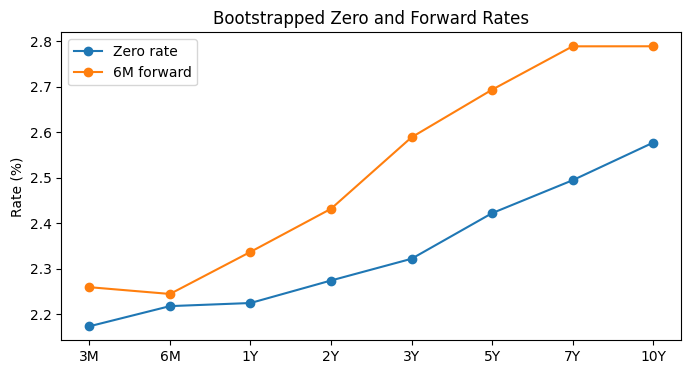

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(snapshot))
ax.plot(x, snapshot["zero_rate"] * 100, marker="o", label="Zero rate")
ax.plot(x, snapshot["fwd_6m"] * 100, marker="o", label="6M forward")
ax.set_xticks(x, snapshot["tenor"])
ax.set_ylabel("Rate (%)")
ax.set_title("Bootstrapped Zero and Forward Rates")
ax.legend()
plt.show()

## 3. Bootstrap validation

A useful sanity check is whether each rate helper can recover the original market quote from the completed term structure. Errors should be close to numerical precision for instruments used directly in the bootstrap.

In [6]:
repricing = curve_repricing_table(curve_meta)
repricing

,instrument,tenor,market_quote,implied_quote,error_bp
0,Deposit,1M,0.0210,0.0210,1.324184e-09
1,Deposit,3M,0.0215,0.0215,-1.009609e-11
2,Deposit,6M,0.0220,0.0220,-4.322931e-11
3,Swap,1Y,0.0225,0.0225,-9.367507e-13
4,Swap,2Y,0.0230,0.0230,1.249001e-12
5,Swap,3Y,0.0235,0.0235,-2.740863e-12
6,Swap,5Y,0.0245,0.0245,4.818021e-10
7,Swap,7Y,0.0252,0.0252,6.230433e-10
8,Swap,10Y,0.0260,0.0260,0.000000e+00


In [7]:
print("Maximum absolute repricing error (bp):", repricing["error_bp"].abs().max())

Maximum absolute repricing error (bp): 1.324183818152136e-09
